# Commonwealth Edison hourly demand

This notebook examines EIA's **Commonwealth Edison (`CE`) subregion inside PJM**. It is closer to Chicago than PJM-wide demand, but it is still a utility zone rather than neighborhood-level metering.

Each `value` is energy demanded during one UTC hour, measured in MWh. Run the ComEd ingestion script before running this notebook.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "CLAUDE.md").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside urban-metrics-forecasting.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from features.energy.engineer import clean_outliers

RAW = ROOT / "data/raw/energy/eia_demand_comed.parquet"
RUN = ROOT / "data/processed/energy/xgboost_comed"
MAX_DEMAND = 50_000
raw = pd.read_parquet(RAW)
plt.rcParams.update({"figure.figsize": (11, 4.5), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .2})

## Coverage and source contract

The code verifies that every row belongs to `parent=PJM`, `subba=CE`, and uses MWh. The file may stop before today because EIA subregion reports arrive after a delay.

In [2]:
assert raw.parent.eq("PJM").all()
assert raw.subba.eq("CE").all()
assert raw["value-units"].eq("megawatthours").all()
period = pd.to_datetime(raw.period, utc=True)
values = pd.to_numeric(raw.value, errors="coerce")
expected = pd.date_range(period.min(), period.max(), freq="h")
summary = pd.Series({
    "Rows returned": len(raw), "First UTC hour": period.min(), "Last UTC hour": period.max(),
    "Duplicate hours": int(period.duplicated().sum()),
    "Hours absent inside source span": len(expected) - period.nunique(),
    "Missing/nonnumeric values": int(values.isna().sum()),
    "Negative values": int(values.lt(0).sum()),
    "Values at/above 50,000 MWh": int(values.ge(MAX_DEMAND).sum()),
}, name="value")
display(summary.to_frame())
display(raw.head())

,value
Rows returned,58635
First UTC hour,2020-01-01 00:00:00+00:00
Last UTC hour,2026-09-19 04:00:00+00:00
Duplicate hours,0
Hours absent inside source span,242
Missing/nonnumeric values,0
Negative values,0
"Values at/above 50,000 MWh",1


,period,subba,subba-name,parent,parent-name,value,value-units
0,2020-01-01 00:00:00+00:00,CE,Commonwealth Edison zone,PJM,"PJM Interconnection, LLC",11957,megawatthours
1,2020-01-01 01:00:00+00:00,CE,Commonwealth Edison zone,PJM,"PJM Interconnection, LLC",11644,megawatthours
2,2020-01-01 02:00:00+00:00,CE,Commonwealth Edison zone,PJM,"PJM Interconnection, LLC",11307,megawatthours
3,2020-01-01 03:00:00+00:00,CE,Commonwealth Edison zone,PJM,"PJM Interconnection, LLC",10983,megawatthours
4,2020-01-01 04:00:00+00:00,CE,Commonwealth Edison zone,PJM,"PJM Interconnection, LLC",10649,megawatthours


## Cleaning rule

The training pipeline restores absent UTC hours and leaves them missing. It masks negative, nonnumeric, infinite, and values at or above 50,000 MWh. Nothing is interpolated. The threshold removes a six-figure source error while remaining well above the observed plausible range; it is recorded with every model run.

In [3]:
largest = raw.nlargest(10, "value")[["period", "value"]]
display(largest)
demand = clean_outliers(raw, MAX_DEMAND).set_index("period")["value"]
print(f"Complete timeline: {len(demand):,} hours; usable: {demand.notna().sum():,}; missing/masked: {demand.isna().sum():,}")

,period,value
5878,2020-09-03 21:00:00+00:00,142142
31848,2023-08-24 22:00:00+00:00,22529
31847,2023-08-24 21:00:00+00:00,22436
31849,2023-08-24 23:00:00+00:00,22306
31846,2023-08-24 20:00:00+00:00,22156
31824,2023-08-23 22:00:00+00:00,21985
31825,2023-08-23 23:00:00+00:00,21908
31823,2023-08-23 21:00:00+00:00,21806
31850,2023-08-25 00:00:00+00:00,21791
31845,2023-08-24 19:00:00+00:00,21710


  Masked 1 invalid/missing demand values; inserted 242 missing hours (no interpolation)
Complete timeline: 58,877 hours; usable: 58,634; missing/masked: 243


## Demand over time

The daily line uses the mean of hourly MWh readings. A day is plotted only when all 24 UTC hours are present, so gaps are visible rather than silently averaged away.

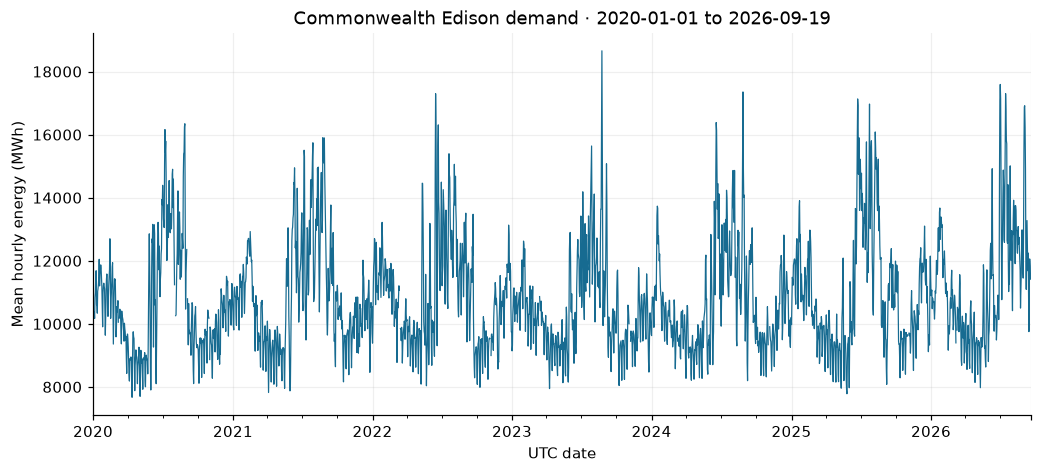

In [4]:
daily = demand.resample("D").agg(["mean", "count"])
daily["mean"].where(daily["count"].eq(24)).plot(color="#176b91", linewidth=.8)
plt.title(f"Commonwealth Edison demand · {demand.index.min():%Y-%m-%d} to {demand.index.max():%Y-%m-%d}")
plt.ylabel("Mean hourly energy (MWh)"); plt.xlabel("UTC date"); plt.show()

## Hourly and monthly patterns

The latest complete calendar year is used so a partial 2026 does not distort the profiles. Hours are converted to Chicago local time for the clock-hour chart.

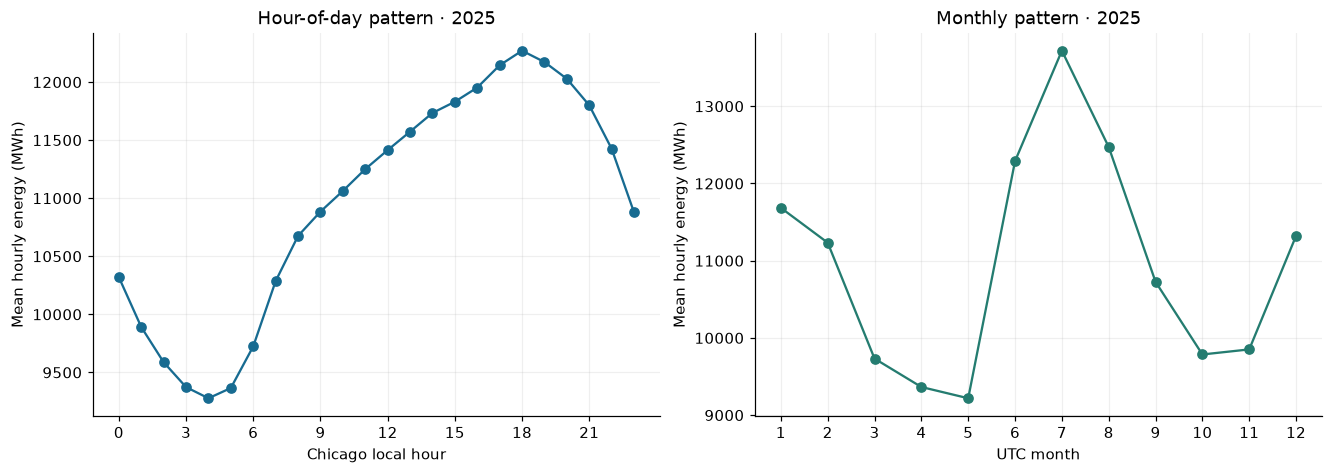

In [5]:
year_ends = demand.groupby(demand.index.year).agg(["count", "size"])
full_years = [y for y in year_ends.index if demand[demand.index.year == y].index.min() == pd.Timestamp(f"{y}-01-01", tz="UTC") and demand[demand.index.year == y].index.max() == pd.Timestamp(f"{y+1}-01-01", tz="UTC") - pd.Timedelta(hours=1)]
PROFILE_YEAR = max(full_years)
profile = demand[demand.index.year == PROFILE_YEAR]
local = profile.copy(); local.index = local.index.tz_convert("America/Chicago")
fig, axes = plt.subplots(1,2,figsize=(12,4.2),layout="constrained")
local.groupby(local.index.hour).mean().plot(ax=axes[0], marker="o", color="#176b91")
axes[0].set(title=f"Hour-of-day pattern · {PROFILE_YEAR}", xlabel="Chicago local hour", ylabel="Mean hourly energy (MWh)", xticks=range(0,24,3))
profile.groupby(profile.index.month).mean().plot(ax=axes[1], marker="o", color="#247c70")
axes[1].set(title=f"Monthly pattern · {PROFILE_YEAR}", xlabel="UTC month", ylabel="Mean hourly energy (MWh)", xticks=range(1,13))
plt.show()

## First ComEd model result

The model trains on 2020–2023, selects trees using 2024, and evaluates once on 2025. It predicts one hour ahead using actual demand available through the previous hour. Lower MAE and RMSE are better. This is a historical rolling backtest, not a live forecast.

,mae,rmse,peak_mae
xgboost,117.35,177.88,263.36
previous_hour,298.95,388.37,517.22
yesterday,780.20,1098.83,1468.24
last_week,1194.70,1713.29,2693.60


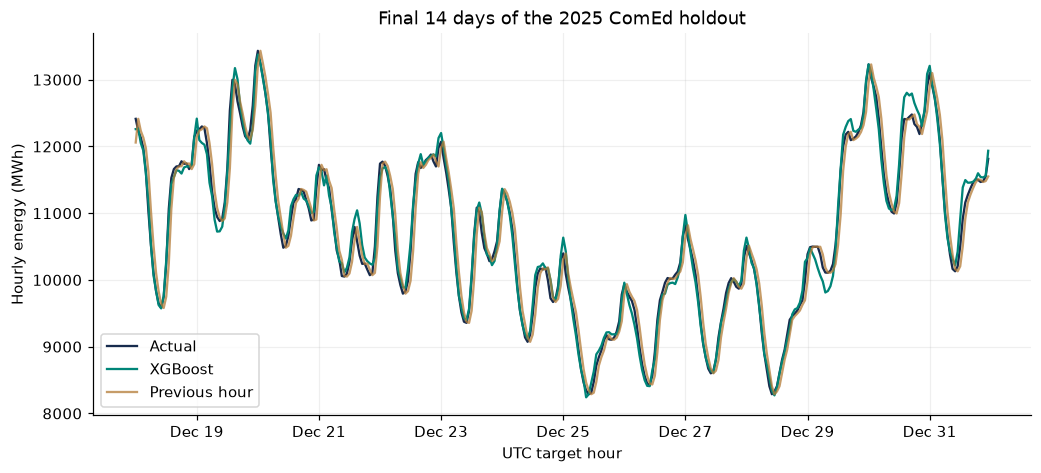

XGBoost MAE is **117.3 MWh**, versus **298.9 MWh** for the strongest simple baseline—a **60.7% reduction**.

In [6]:
metrics = json.loads((RUN / "metrics.json").read_text())
scores = pd.DataFrame(metrics["scores"]["test"]).T[["mae", "rmse", "peak_mae"]]
display(scores.round(2))
preds = pd.read_csv(RUN / "test_predictions.csv", parse_dates=["period"])
last = preds.tail(24*14)
plt.plot(last.period, last.actual, label="Actual", color="#172b4d")
plt.plot(last.period, last.xgboost, label="XGBoost", color="#008578")
plt.plot(last.period, last.previous_hour, label="Previous hour", color="#b47b36", alpha=.75)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.title("Final 14 days of the 2025 ComEd holdout")
plt.ylabel("Hourly energy (MWh)"); plt.xlabel("UTC target hour"); plt.legend(); plt.show()
model_mae=scores.loc["xgboost","mae"]; base_mae=scores.loc["previous_hour","mae"]
display(Markdown(f"XGBoost MAE is **{model_mae:,.1f} MWh**, versus **{base_mae:,.1f} MWh** for the strongest simple baseline—a **{(1-model_mae/base_mae)*100:.1f}% reduction**."))

## What this establishes—and what comes next

The ComEd target is geographically better aligned with Chicago, and the demand-only XGBoost baseline beats the previous-hour baseline on the 2025 holdout. Missing intervals reduce evaluation coverage and remain disclosed in the training report.

The next controlled experiment should add Chicago weather to this same target while preserving the same splits. Compare demand-only and weather-enhanced models on identical eligible hours. Do not claim neighborhood forecasts from ComEd-zone demand; that requires a separate local allocation method and validation.